# Práctica 04 : Análisis de datos exploratorio con python y jupiter notebook en un dataset de productos de amazon store

**Programa de estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de datos para negocios digitales \
**Docente:** M.T.I Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026

### Unidad 2: Preparación de los datos

**Nombre del Estudiante:** Brandon Diego Islas Lizardi \
**Matricula:** 230550 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #FF4081 0%, #880E4F 100%);
padding: 30px;
border-radius: 15px;
text-align: center;">

<h1 style="color: white; font-size: 2.2em; margin: 0; font-family: sans-serif;">
Productos de Amazon Store – Análisis Exploratorio de Datos
Completo & Aprendizaje Automático Predictivo (ML)
</h1>

<p style="color: #FCE4EC; font-size: 1.1em; margin-top: 10px; font-family: sans-serif;">  
Predicción de Precios • Análisis de Categorías •
Ingeniería de Funcionalidades • Comparación de Modelos
</p>

</div>

## Tabla de Contenidos 
| # | Sección | Descripción |
|---|---|---|
| 1 |[Instalaciones & carga de datos](#s1). | Librerias, carga del CVS, primeros comandos de estructura |
| 2 |[Diccionario de datos](#s2) |Explicacion del contenido de columnas y calcular el % de datos faltantes |
| 3 |[Limpieza de datos](#s3) |Aplicacion de metodos basicos de limpieza (elimininacion duplicados,datos nulos) |


## 1. Instalaciones & Carga de Datos <a id='s1'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">

<b>Dataset:</b> Amazon India Listas de Productos – 1,436 productos entre Libros, Kindle, Deportes & más<br>

<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>

<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in

</div>

In [23]:
# ============================================================
# SECTION 1 — Setup & Data Loading
# ============================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import shapiro, kruskal, spearmanr, mannwhitneyu, f_oneway

# ML
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(f'✅ Pandas  : {pd.__version__}')
print(f'✅ NumPy   : {np.__version__}')
print(f'✅ XGBoost : {XGB_AVAILABLE}')
print('✅ All libraries loaded!')

✅ Pandas  : 2.3.3
✅ NumPy   : 2.3.5
✅ XGBoost : False
✅ All libraries loaded!


In [2]:
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f"✅ Shape: {df_raw.shape}")
print(f"✅ Columns: {df_raw.columns.tolist()}")

df_raw.head(3)

✅ Shape: (1446, 17)
✅ Columns: ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2.- Diccionario de datos del DataFrame.

In [3]:
col_info = {
    'url': 'URL del Producto en Amazon.in',
    'asin': 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name': 'Nombre o Título del Producto',
    'overview': 'Breve Reseña del Producto (mayoría vacío [])',
    'price': 'Precio como string (e.g. "₹1,600.00")',
    'currency': 'Código de Divisa (todas en INR)',
    'availability': 'Texto del Status del Stock (Inventario)',
    'brand': 'Nombre de la Marca/Autor',
    'about_item': 'Detalles/Especificaciones (mayoría faltante)',
    'img_source': 'URLs de Imágenes del Producto',
    'description': 'Descripción detallada y completa (mayoría faltante)',
    'specifications': 'Especificaciones Técnicas',
    'primary_category': 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1': 'Subcategoría de nivel 1',
    'category_2': 'Subcategoría de nivel 2',
    'category_3': 'Subcategoría de nivel 3',
    'breadcrumbs': 'Ruta de categorías',
}

print('Diccionario por columnas:\n')

for col, desc in col_info.items():
    # Validamos si la columna realmente existe en el DataFrame
    if col in df_raw.columns:
        missing_pct = df_raw[col].isnull().mean() * 100
        print(
            f'{col:20s} | '
            f'{desc:45s} | '
            f'missing: {missing_pct:.0f}%'
        )
    else:
        # Si no existe, te lo reporta en lugar de lanzar un error
        print(
            f'{col:20s} | '
            f'{desc:45s} | '
            f'missing: ¡NO ENCONTRADA EN DATAFRAME!'
        )

Diccionario por columnas:

url                  | URL del Producto en Amazon.in                 | missing: ¡NO ENCONTRADA EN DATAFRAME!
asin                 | Número Estandarizado de Identificación por Amazon (unique ID) | missing: 0%
name                 | Nombre o Título del Producto                  | missing: 0%
overview             | Breve Reseña del Producto (mayoría vacío [])  | missing: 0%
price                | Precio como string (e.g. "₹1,600.00")         | missing: 24%
currency             | Código de Divisa (todas en INR)               | missing: 24%
availability         | Texto del Status del Stock (Inventario)       | missing: 34%
brand                | Nombre de la Marca/Autor                      | missing: 1%
about_item           | Detalles/Especificaciones (mayoría faltante)  | missing: 91%
img_source           | URLs de Imágenes del Producto                 | missing: 1%
description          | Descripción detallada y completa (mayoría faltante) | missing: 92%
specifi

## 3. Limpieza de datos

<div style="background:#e6f2ff; padding:12px; border-left:4px solid #0066cc; border-radius:5px; color:#003366;">
<b>Pasos clave para la limpieza:</b><br>
• Parsear los precios de strings como "1,600.00" → float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [4]:
# ============================================================
# SECTION 2 - Data Cleaning
# ============================================================

df = df_raw.copy()

# ------------------------------------------------------------
# Parse price
# ------------------------------------------------------------
def clean_price(p):
    if pd.isna(p):
        return np.nan

    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)

    return float(m.group()) if m else np.nan


df['price_clean'] = df['price'].apply(clean_price)

# ------------------------------------------------------------
# Standardize availability
# ------------------------------------------------------------
def clean_availability(a):
    if pd.isna(a):
        return 'Unknown'

    a = str(a).strip().lower()

    if 'in stock' in a:
        return 'In Stock'

    if 'unavailable' in a:
        return 'Unavailable'

    if '1 to 3' in a:
        return 'Ships 1-3 weeks'

    if '4 to 5' in a or '6 to' in a or '9 to' in a:
        return 'Ships 4-14 days'

    if '13 to 14' in a or '2 to 3 weeks' in a:
        return 'Ships 2+ weeks'

    if 'only' in a and 'left' in a:
        return 'Low Stock'

    if '2 to 3 days' in a or '1 to 2 days' in a:
        return 'Ships 1-3 days'

    return 'Other'


df['avail_clean'] = df['availability'].apply(clean_availability)

# ------------------------------------------------------------
# Text length features
# ------------------------------------------------------------
df['name_length'] = df['name'].fillna('').str.len()
df['name_words'] = df['name'].fillna('').str.split().str.len()
df['has_brand'] = df['brand'].notna().astype(int)
df['has_desc'] = df['description'].notna().astype(int)
df['has_specs'] = df['specifications'].notna().astype(int)

# ------------------------------------------------------------
# Duplicate check
# ------------------------------------------------------------
dupes = df.duplicated(subset='asin').sum()

print(f'✓ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✓ Duplicate ASINs: {dupes}')
print(f'✓ Availability categories: {df["avail_clean"].value_counts().to_dict()}')

df[['name', 'price_clean', 'avail_clean',
    'primary_category', 'name_length']].head(5)

✓ Price parsed: 1,094 / 1,446 products
✓ Duplicate ASINs: 5
✓ Availability categories: {'In Stock': 607, 'Unknown': 486, 'Ships 1-3 weeks': 122, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 80, 'Other': 20, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


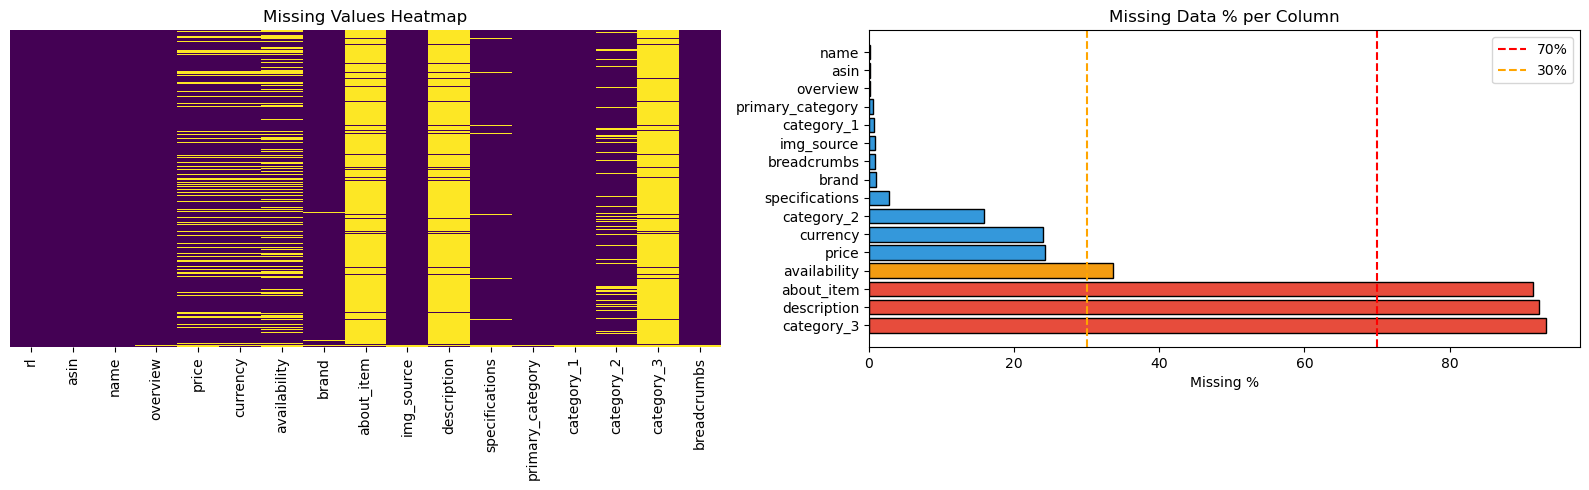

                  Missing Count  Missing Pct
category_3                 1349         93.3
description                1334         92.3
about_item                 1323         91.5
availability                486         33.6
price                       350         24.2
currency                    347         24.0
category_2                  229         15.8
specifications               39          2.7
brand                        14          1.0
breadcrumbs                  11          0.8
img_source                   11          0.8
category_1                   10          0.7
primary_category              7          0.5
overview                      3          0.2
asin                          2          0.1
name                          2          0.1


In [5]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df_raw.isnull().sum(),
    'Missing Pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Aquí corregí 'Viridis' por 'viridis' con minúscula
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]

# Dibujar barras solo si hay columnas con valores faltantes
if not mv.empty:
    axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
    axes[1].axvline(70, color='red', linestyle='--', label='70%')
    axes[1].axvline(30, color='orange', linestyle='--', label='30%')
    axes[1].set_xlabel('Missing %')
    axes[1].set_title('Missing Data % per Column')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No hay valores faltantes', 
                 horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4.Ingenieria de caracteristicas (Feature Engineering)

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>Ejemplo Cotidiano:</b> Un agente inmobiliario no solo utiliza los metros cuadrados brutos, sino que también considera la ubicación, la antiguedad y 
el estado. Nosotros hacemos lo mismo: extraemos información más valiosa del texto sin procesar y las categorías.
</div>

In [6]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

# print(f'✅ Total Caracteriscas (Atributos) Procesadas (Features Engineered): {len(df.columns)}')
print('\nPrecio por cada tipo (tier) de distribucion:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)


Precio por cada tipo (tier) de distribucion:
price_tier
1_budget     104
2_low        285
3_mid        319
4_premium    260
5_luxury     126
Unknown      352


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5.Análisis Univariante 📊

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>Las gráficas que generamos nos ayudan a visualizar el inventario de los productos de mi dataset y a mostrar qué grupos tienen el mayor volumen de datos. También nos muestran la disponibilidad de los artículos; en palabras simples,<b
nos dicen si hay stock o si se trata de un producto agotado.
    </div>

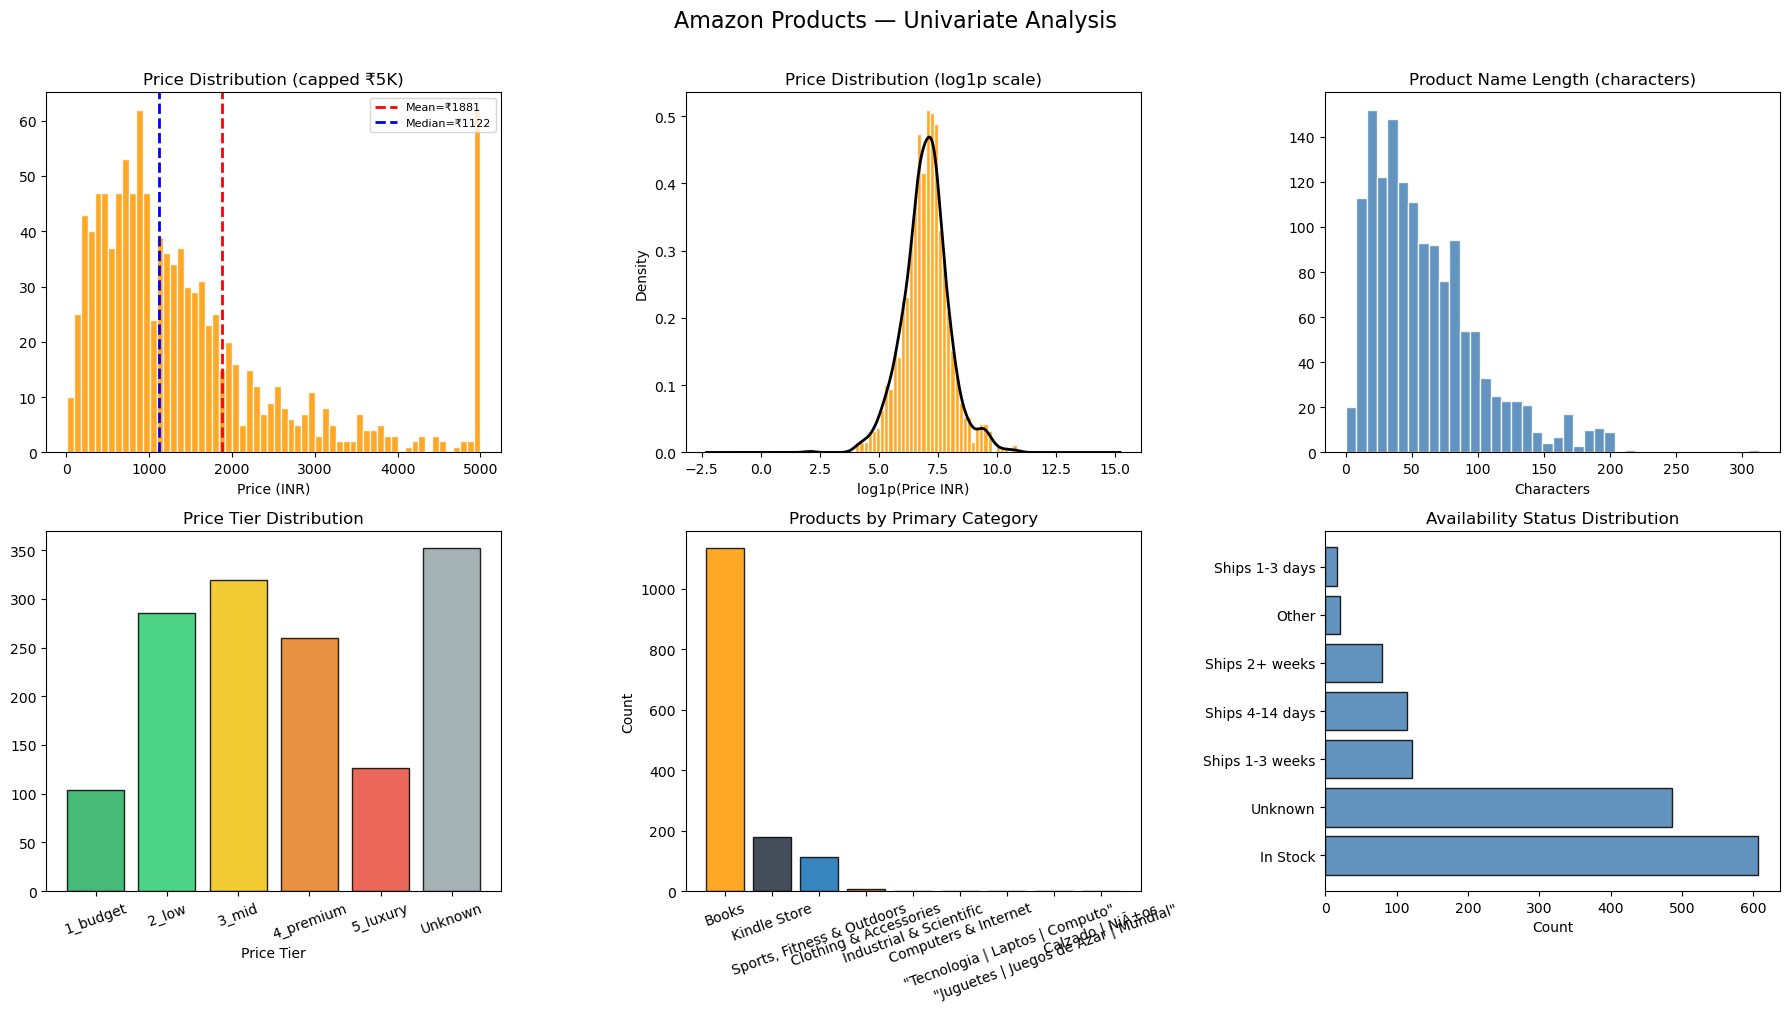

Shapiro-Wilk (log price, n=500): stat=0.9823, p=0.000009
Price is still non-normal after log transform

Price stats (INR):
count     1087.00
mean      1881.16
std       3339.62
min          7.00
25%        612.53
50%       1122.00
75%       1850.00
max      50555.00


In [7]:
# ============================================================
# SECTION 4 — Univariate Analysis
# ============================================================
from scipy.stats import shapiro
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Price raw
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Mean=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Median=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Price Distribution (capped ₹5K)')
axes[0,0].set_xlabel('Price (INR)'); axes[0,0].legend(fontsize=8)

# Price log
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Price Distribution (log1p scale)')
axes[0,1].set_xlabel('log1p(Price INR)')

# Name length
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Product Name Length (characters)')
axes[0,2].set_xlabel('Characters')

# Price tier
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Price Tier Distribution')
axes[1,0].set_xlabel('Price Tier'); axes[1,0].tick_params(axis='x', rotation=20)

# Primary category
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Products by Primary Category')
axes[1,1].set_ylabel('Count'); axes[1,1].tick_params(axis='x', rotation=20)

# Availability
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Availability Status Distribution')
axes[1,2].set_xlabel('Count')

plt.suptitle('Amazon Products — Univariate Analysis', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

# Normality test
stat, p = shapiro(df_priced['log_price'].sample(min(500, len(df_priced)), random_state=42))
print(f'Shapiro-Wilk (log price, n=500): stat={stat:.4f}, p={p:.6f}')
print(f'Price is {"normally distributed after log transform" if p > 0.05 else "still non-normal after log transform"}')
print(f'\nPrice stats (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())

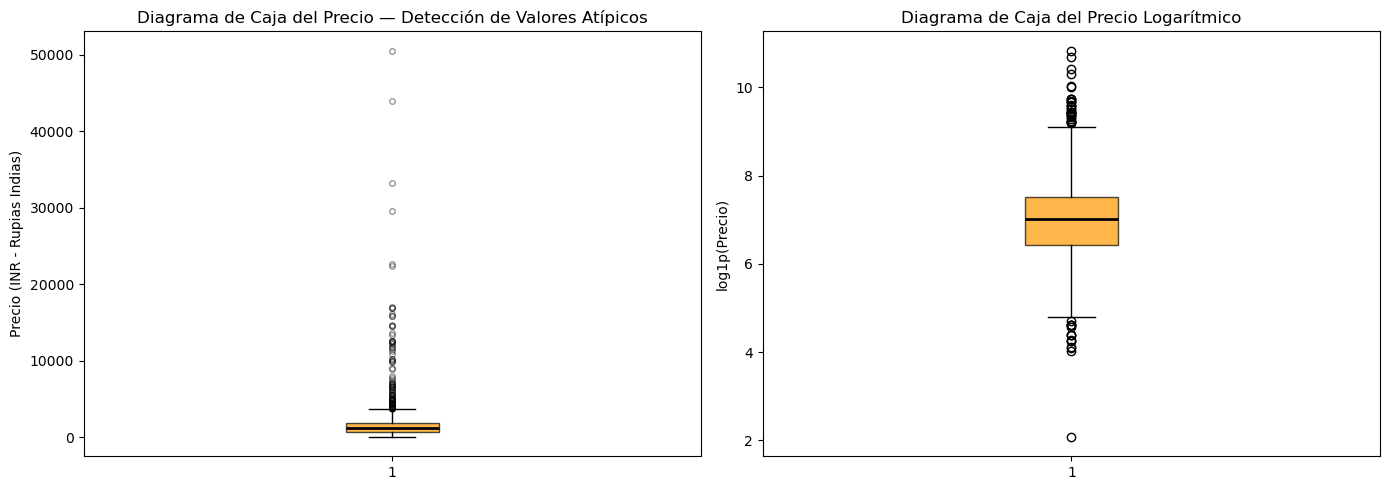

Valores atípicos por método IQR: 93 (8.6%)
Rango de precios (sin valores atípicos): ₹-1244 – ₹3706

Top 10 de productos más caros:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     

In [8]:
# ==============================================================================
# ANÁLISIS DE VALORES ATÍPICOS (OUTLIERS) — DIAGRAMA DE CAJA (BOXPLOT) e IQR
# ==============================================================================

# Creamos una figura con 1 fila y 2 columnas para mostrar dos gráficos lado a lado.
# El tamaño asignado de la figura completa es de 14 de ancho por 5 de alto.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Diagrama de Caja del Precio Original ---

# Dibuja un boxplot de los precios limpios en la primera posición [0].
# 'patch_artist=True' permite rellenar la caja con color.
# 'boxprops' define el color naranja de Amazon con un 70% de opacidad.
# 'medianprops' resalta la línea de la mediana en color negro y grosor de 2.
# 'flierprops' configura los puntos que representan los valores atípicos (en color rojo y semi-transparentes).
axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))

# Título y etiquetas en español para el primer gráfico
axes[0].set_title('Diagrama de Caja del Precio — Detección de Valores Atípicos')
axes[0].set_ylabel('Precio (INR - Rupias Indias)')


# --- Gráfico 2: Diagrama de Caja del Precio en Escala Logarítmica ---

# Dibuja un boxplot de la variable transformada 'log_price' en la segunda posición [1].
# Se usan los mismos estilos visuales para mantener consistencia.
axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))

# Título y etiquetas en español para el segundo gráfico
# Al aplicar logaritmo, se reduce la distancia visual que causan los productos caros.
axes[1].set_title('Diagrama de Caja del Precio Logarítmico')
axes[1].set_ylabel('log1p(Precio)')

# Ajusta el espacio para que los títulos y nombres de los ejes no se encimen.
plt.tight_layout()

# Muestra en pantalla el lienzo final con los dos diagramas de caja.
plt.show()


# --- Cálculo Matemático del Rango Intercuartílico (Método IQR) ---

# Calculamos el Primer Cuartil (Q1 - percentil 25) y el Tercer Cuartil (Q3 - percentil 75) del precio.
Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])

# El IQR es la distancia o rango que abarca el 50% de los datos centrales.
IQR = Q3 - Q1

# Identificamos como "outliers" o atípicos a los registros que estén:
# - Por debajo de: Q1 - (1.5 * IQR)
# - Por encima de: Q3 + (1.5 * IQR)
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]

# Imprime la cantidad total de productos atípicos encontrados y el porcentaje que representan en el dataset.
print(f'Valores atípicos por método IQR: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')

# Muestra el rango "normal" de precios calculado matemáticamente libre de valores extremos extremos.
print(f'Rango de precios (sin valores atípicos): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')


# --- Visualización de los Productos de Mayor Valor ---

# Imprime un encabezado para identificar los artículos más caros de la muestra.
print(f'\nTop 10 de productos más caros:')

# Ordena el dataset de mayor a menor según 'price_clean' y extrae las primeras 10 filas.
# Selecciona solo las columnas de 'name' (nombre), 'price_clean' (precio) y 'primary_category' (categoría).
# '.to_string(index=False)' oculta los números de índice de fila para que la tabla se imprima limpia.
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))

## 6.Análisis de Categorías

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>Este análisis nos sirve para ver cuáles pasillos de la tienda acumulan más mercancía y cuáles manejan los precios más altos. Al revisar el volumen de artículos y cruzarlo con sus costos, podemos descubrir en qué partes del negocio se concentra el dinero real. Técnicamente, esto nos permite evaluar cómo se relacionan las variables de tipo texto (las categorías) con los valores numéricos (los precios), ayudándonos a identificar la concentración de los datos y el valor total acumulado antes de entrenar cualquier modelo de predicción. <b>
    </div>

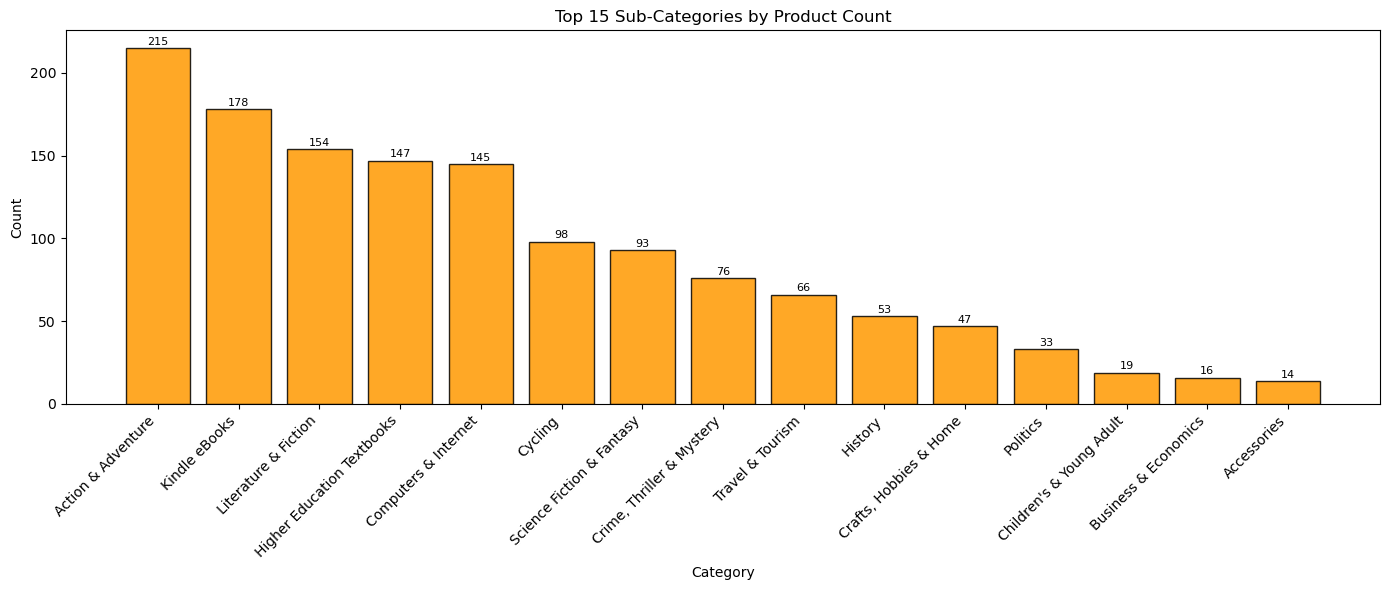

In [9]:
# ==============================================================================
# SECCIÓN 5 — ANÁLISIS DE CATEGORÍAS (CATEGORY ANALYSIS)
# ==============================================================================

# Cuenta cuántos productos pertenecen a cada subcategoría ('category_1').
# Con '.head(15)' seleccionamos únicamente las 15 subcategorías que tienen más productos en el dataset.
top15_cat1 = df['category_1'].value_counts().head(15)

# Crea el lienzo de la gráfica definiendo un tamaño de 14 de ancho por 6 de alto.
plt.figure(figsize=(14, 6))

# Dibuja un gráfico de barras verticales.
# Coloca los nombres de las 15 subcategorías en el eje X y sus cantidades en el eje Y.
# El color elegido es el naranja de Amazon ('#FF9900') con bordes negros y un 85% de opacidad.
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)

# --- Bucle para agregar etiquetas de datos (números sobre las barras) ---
# Recorre cada barra de la gráfica al mismo tiempo que su valor numérico correspondiente.
for bar, val in zip(bars, top15_cat1.values):
    # 'plt.text' coloca un texto en coordenadas específicas:
    # Eje X: El centro exacto de la barra actual (posición inicial X + la mitad de su ancho).
    # Eje Y: Justo arriba de la barra (la altura de la barra + 2 unidades de margen para que no choque).
    # 'str(val)' convierte el número a texto, 'ha='center'' lo alinea al centro y se define un tamaño de letra de 8.
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', fontsize=8)

# Configura el título principal del gráfico y las etiquetas informativas de los ejes X e Y.
plt.title('Top 15 Sub-Categories by Product Count')
plt.xlabel('Category')
plt.ylabel('Count')

# Rota los nombres del eje X 45 grados y los alinea a la derecha ('ha='right'') para evitar que se encimen y sean legibles.
plt.xticks(rotation=45, ha='right')

# Ajusta automáticamente los márgenes de la imagen para que ninguna etiqueta ni texto quede recortado en los bordes.
plt.tight_layout()

# Despliega en pantalla el gráfico final con sus respectivas barras y números.
plt.show()

C:\Users\PC-25\AppData\Local\Temp\ipykernel_16812\1140488297.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(cat_groups, labels=cat_price.index, patch_artist=True,


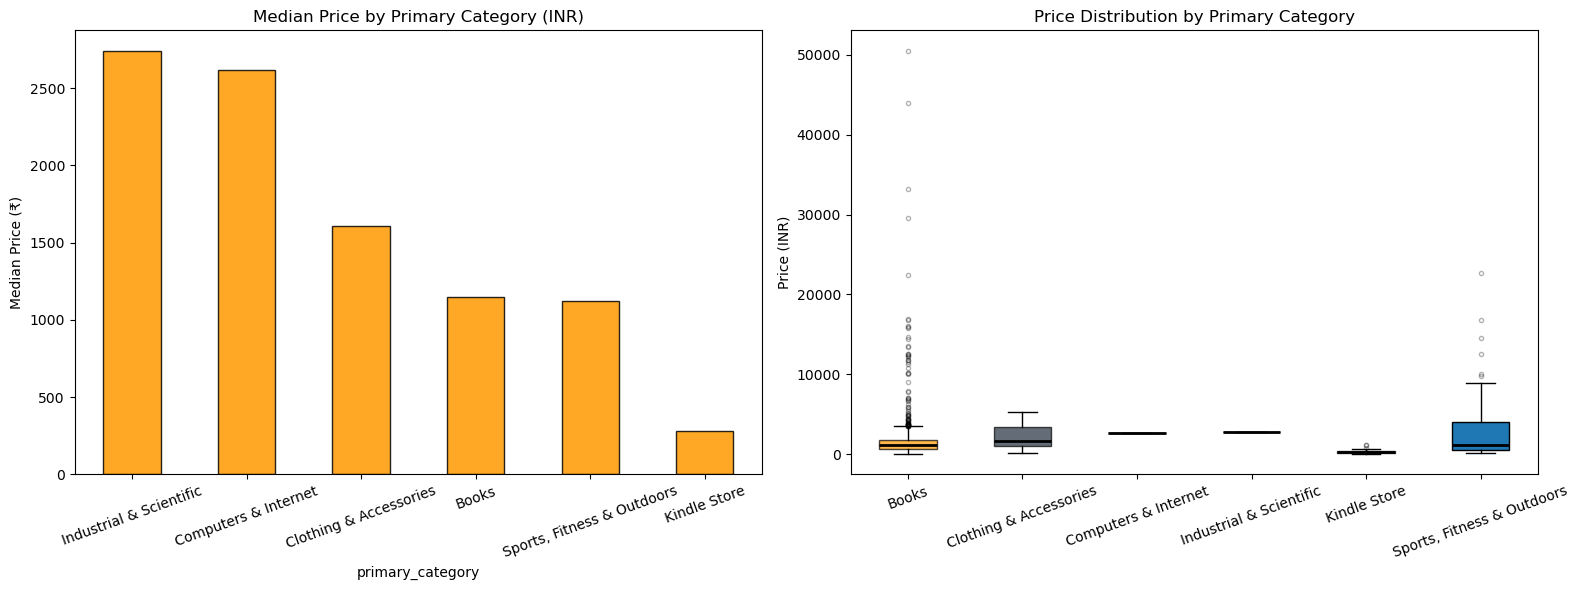

Price stats by primary category:
                              mean  median  count
primary_category                                 
Books                       1825.6  1145.0    955
Clothing & Accessories      2249.2  1606.5      6
Computers & Internet        2615.0  2615.0      1
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93


In [10]:
# --- Configuración de los Gráficos ---
# Creamos una figura con 1 fila y 2 columnas para mostrar dos gráficos lado a lado.
# Definimos un tamaño de 16 de ancho por 6 de alto.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Cálculo de Estadísticas por Categoría ---
# Agrupamos los datos por la columna 'primary_category' (Categoría Principal).
# Usamos '.agg()' para calcular al mismo tiempo: el promedio ('mean'), la mediana ('median') y la cantidad de productos ('count').
# Redondeamos los resultados a 1 decimal (.round(1)).
cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)

# --- Gráfico 1: Barras de la Mediana de Precios ---
# Tomamos la columna de medianas, la ordenamos de mayor a menor y la graficamos en formato de barras (.plot.bar).
# 'ax=axes[0]' le indica a Python que este gráfico va en la primera posición (izquierda).
# Usamos el color naranja de Amazon, bordes negros y una opacidad del 85%.
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)

# Agregamos el título y la etiqueta del eje Y en el primer gráfico.
axes[0].set_title('Median Price by Primary Category (INR)')
axes[0].set_ylabel('Median Price (₹)')
# Rotamos los nombres de las categorías 20 grados para que se lean bien.
axes[0].tick_params(axis='x', rotation=20)


# --- Gráfico 2: Diagrama de Caja (Boxplot) por Categoría ---
# Creamos una lista llamada 'cat_groups'. Para cada categoría, filtramos sus precios limpios y eliminamos los valores nulos (.dropna()).
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]

# Dibujamos los diagramas de caja en la segunda posición (derecha: axes[1]).
# Pasamos la lista de grupos creada antes y le asignamos los nombres de las categorías como etiquetas.
# Configuramos la línea de la mediana en color negro y los valores atípicos (puntos) pequeños y transparentes.
bp = axes[1].boxplot(cat_groups, labels=cat_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))

# --- Personalización de Colores en el Boxplot ---
# Definimos una lista de colores representativos de Amazon.
colors_cat = ['#FF9900','#232F3E','#146EB4','#E47911','#999']

# Recorremos cada una de las "cajas" dibujadas y le asignamos un color de la lista con una opacidad del 70%.
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color); patch.set_alpha(0.7)

# Agregamos el título y la etiqueta del eje Y en el segundo gráfico.
axes[1].set_title('Price Distribution by Primary Category')
axes[1].set_ylabel('Price (INR)')
# Rotamos los nombres de las categorías 20 grados.
axes[1].tick_params(axis='x', rotation=20)


# --- Ajustes de Impresión en Pantalla ---
# Ajustamos los espacios automáticamente para evitar que los textos de ambos gráficos se encimen.
plt.tight_layout()
# Desplegamos la figura en el cuaderno.
plt.show()

# --- Impresión de Tablas en Consola ---
# Imprimimos un texto de encabezado.
print('Price stats by primary category:')
# Convertimos la tabla de estadísticas calculada al inicio en texto y la mostramos completa.
print(cat_price.to_string())

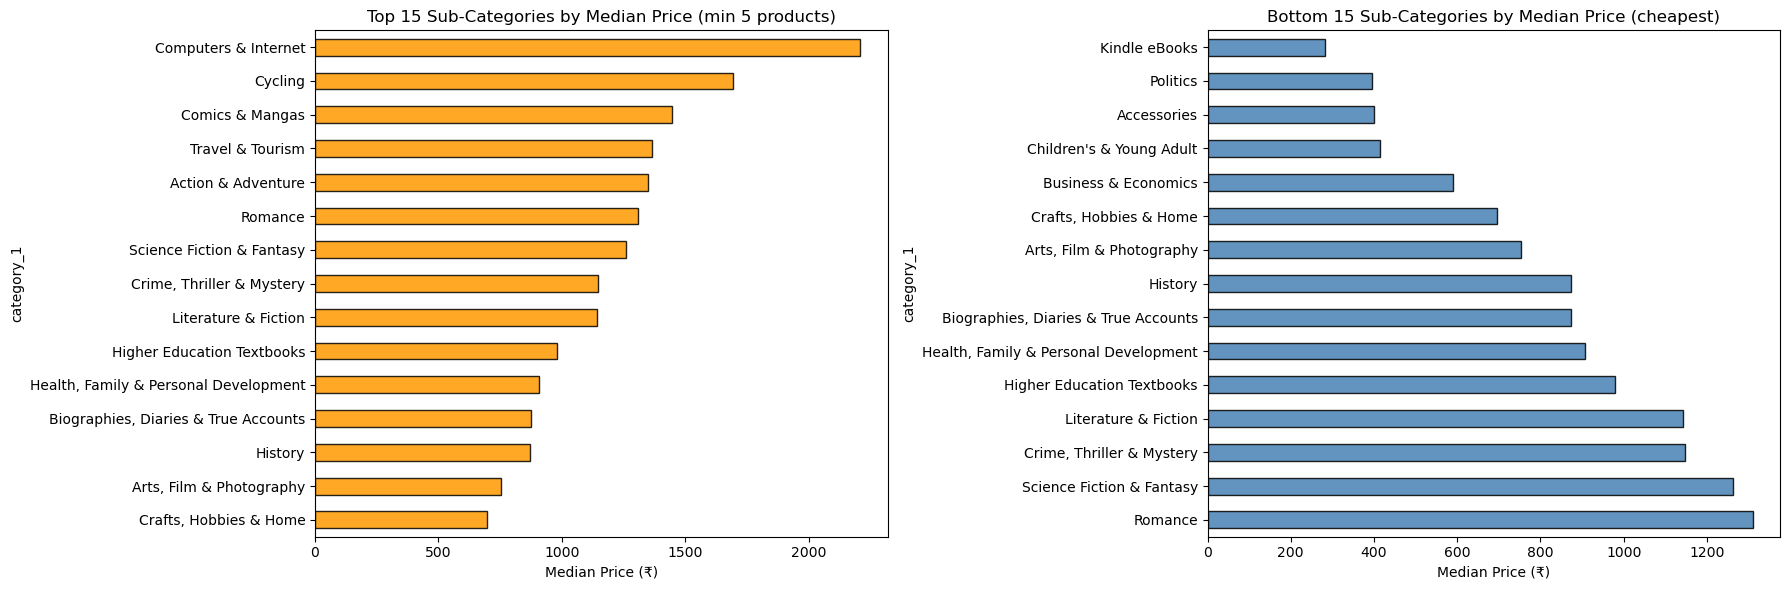

In [11]:
# --- Cálculo de las 15 Subcategorías Más Caras ---
# 1. Agrupamos los datos por la columna 'category_1' (Subcategorías).
# 2. Calculamos la mediana de precio ('median') y contamos cuántos productos tiene cada una ('count').
# 3. '.query('count >= 5')' es un filtro: solo nos interesan subcategorías que tengan 5 o más productos (para evitar que un solo producto muy caro altere el análisis).
# 4. Ordenamos de mayor a menor según su mediana de precio y nos quedamos con el Top 15 (.head(15)).
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

# --- Configuración de los Gráficos ---
# Creamos una figura con 1 fila y 2 columnas para mostrar los dos gráficos lado a lado.
# El tamaño de la figura completa es de 18 de ancho por 6 de alto.
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Gráfico 1: Las 15 Subcategorías con Precios Más Altos ---
# Tomamos el Top 15 de las más caras, las ordenamos de menor a mayor (para que al graficar en horizontal la más cara quede arriba).
# Creamos un gráfico de barras horizontales (.plot.barh) ubicado en la primera posición (izquierda: ax=axes[0]).
# Usamos el color naranja de Amazon con bordes negros y un 85% de opacidad.
top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)

# Agregamos el título descriptivo y la etiqueta del eje X (Precio Mediano en Rupias) al primer gráfico.
axes[0].set_title('Top 15 Sub-Categories by Median Price (min 5 products)')
axes[0].set_xlabel('Median Price (₹)')


# --- Cálculo de las 15 Subcategorías Más Baratas (Económicas) ---
# Hacemos exactamente el mismo proceso: agrupamos, calculamos mediana y cantidad, y filtramos que tengan mínimo 5 productos.
# La diferencia es que aquí ordenamos de menor a mayor (.sort_values('median')) para encontrar las 15 más baratas (.head(15)).
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))

# --- Gráfico 2: Las 15 Subcategorías Más Baratas ---
# Tomamos el grupo de las más baratas, las ordenamos de mayor a menor y creamos el gráfico horizontal en la segunda posición (derecha: ax=axes[1]).
# Para diferenciarlo visualmente del gráfico de productos caros, usamos un color azul acero ('steelblue').
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)

# Agregamos el título descriptivo y la etiqueta del eje X al segundo gráfico.
axes[1].set_title('Bottom 15 Sub-Categories by Median Price (cheapest)')
axes[1].set_xlabel('Median Price (₹)')


# --- Ajustes Finales ---
# Ajusta de forma automática los espacios entre los dos gráficos para evitar que los textos de los ejes se encimen.
plt.tight_layout()

# Muestra la figura con ambos gráficos en pantalla.
plt.show()

## 7.Análisis de Disponibilidad

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>
Este análisis sirve para entender cómo se distribuye el inventario de los productos y
si el hecho de que un artículo esté agotado o disponible tiene alguna relación con su costo. Al cruzar los precios con el estado del stock,
podemos descubrir de forma sencilla si los productos más caros o exclusivos tienden a acabarse más rápido que los normales. Técnicamente, este 
bloque nos permite evaluar una variable categórica discreta mediante proporciones (porcentajes) y formas visuales, ayudándonos a comprobar si existe
patrones importantes en el comportamiento de la tienda antes de pasar a la etapa de predicción con los modelos.<b>
<div>

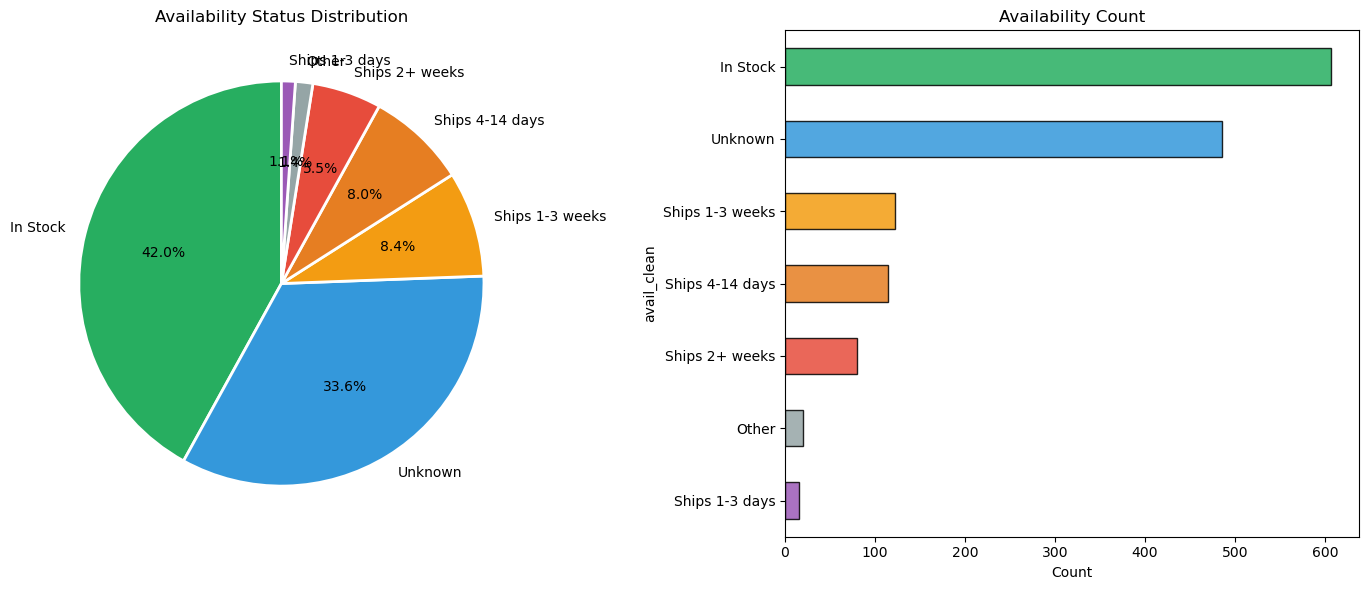

In [12]:
# ============================================================
# SECTION 6 — Availability Analysis
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Availability Status Distribution')

avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Availability Count')
axes[1].set_xlabel('Count')

plt.tight_layout(); plt.show()

C:\Users\PC-25\AppData\Local\Temp\ipykernel_16812\1063884491.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,


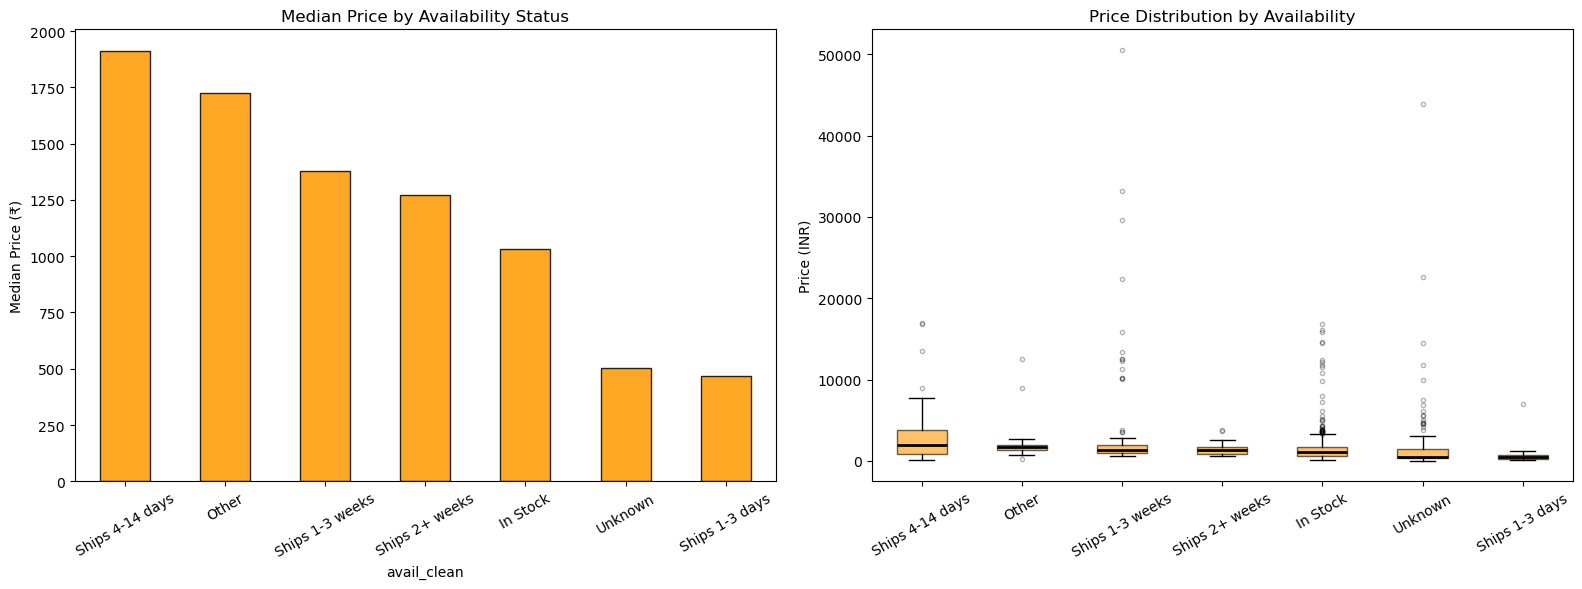

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1724.2  2459.4     20
Ships 1-3 weeks  1377.5  3226.6    122
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1030.0  1490.5    599
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [13]:
# Price by availability status
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print('Price by availability:')
print(avail_price.to_string())

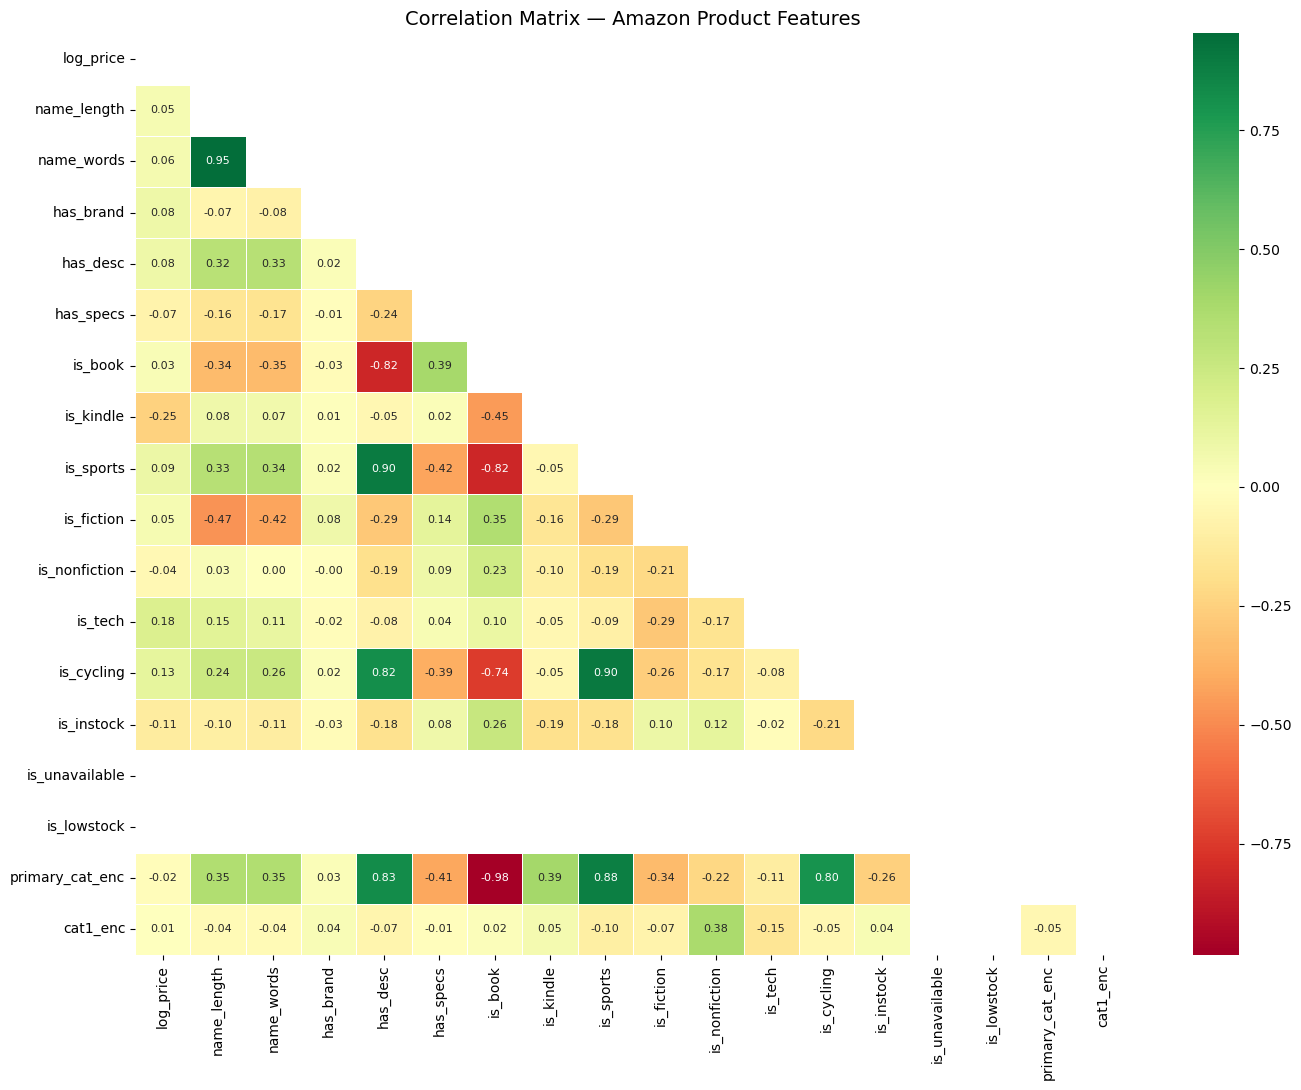

Top correlations with log_price:
is_tech            0.178700
is_cycling         0.126665
is_sports          0.091764
has_brand          0.083788
has_desc           0.083304
name_words         0.055104
is_fiction         0.052686
name_length        0.049775
is_book            0.034124
cat1_enc           0.006765
primary_cat_enc   -0.019787
is_nonfiction     -0.044517
has_specs         -0.074902
is_instock        -0.114018
is_kindle         -0.246647
is_unavailable          NaN
is_lowstock             NaN


In [16]:
# ============================================================
# SECTION 7 — Correlation Analysis
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Matrix — Amazon Product Features', fontsize=14)
plt.tight_layout(); plt.show()

print('Top correlations with log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())

C:\Users\PC-25\AppData\Local\Temp\ipykernel_16812\1063884491.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,


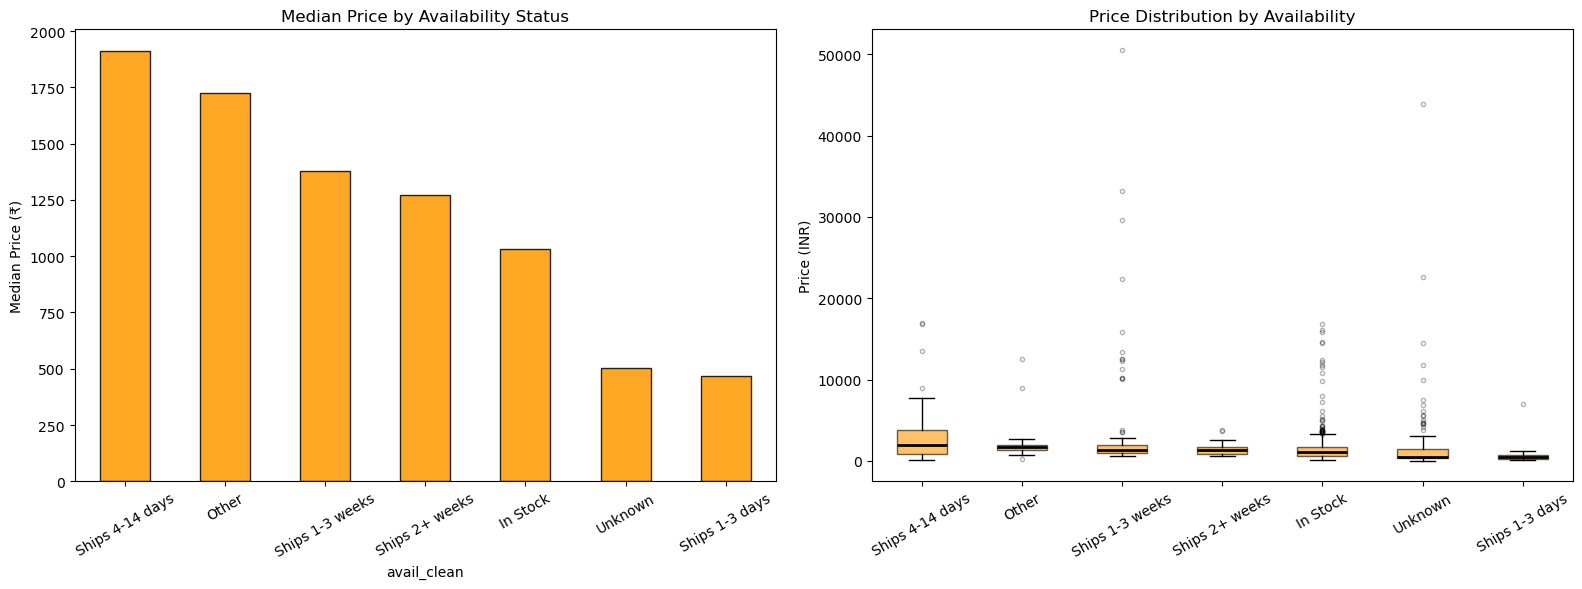

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1724.2  2459.4     20
Ships 1-3 weeks  1377.5  3226.6    122
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1030.0  1490.5    599
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [15]:
# Price by availability status
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print('Price by availability:')
print(avail_price.to_string())

## 8.ANÁLISIS DE CORRELACIÓN

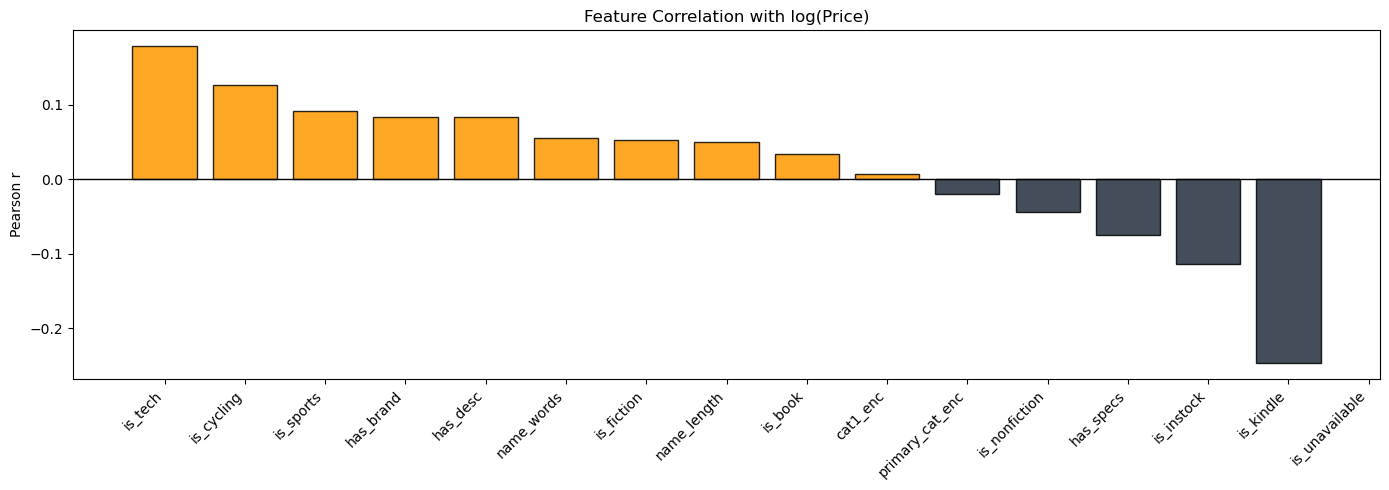

In [17]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Feature Correlation with log(Price)')
plt.ylabel('Pearson r'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

C:\Users\PC-25\AppData\Local\Temp\ipykernel_16812\2946963551.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),


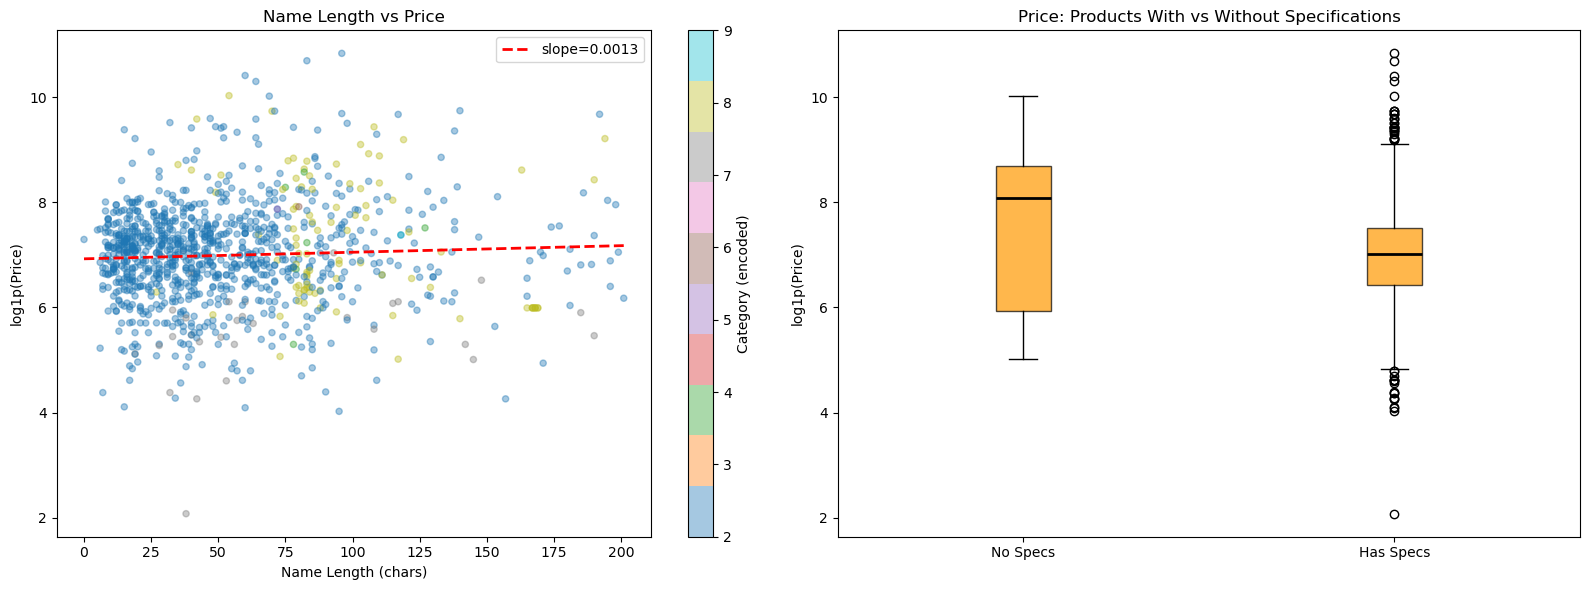

In [18]:
# Scatter: name length vs price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20)
plt.colorbar(sc, ax=axes[0], label='Category (encoded)')
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'slope={m:.4f}')
axes[0].set_xlabel('Name Length (chars)'); axes[0].set_ylabel('log1p(Price)')
axes[0].set_title('Name Length vs Price'); axes[0].legend()

# Price by has_specs
axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                 np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                labels=['No Specs','Has Specs'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Price: Products With vs Without Specifications')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()

In [24]:
# ============================================================
# SECTION 8 — Hypothesis Testing
# ============================================================
alpha = 0.05

def mw_test(name, a, b, la, lb):
    u, p = mannwhitneyu(a.dropna(), b.dropna(), alternative='two-sided')
    print(f'{name}')
    print(f'  {la}: n={len(a.dropna())}, median=₹{a.median():.0f}')
    print(f'  {lb}: n={len(b.dropna())}, median=₹{b.median():.0f}')
    print(f'  Mann-Whitney U={u:.0f}, p={p:.6f}')
    print(f'  RESULT: {"✅ REJECT H0 — Significant difference." if p < alpha else "❌ FAIL TO REJECT H0."}')
    print()
    return p

# H1: Price across primary categories — Kruskal-Wallis
cat_groups_kw = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
                 for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]
cat_labels_kw = [c for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]
h1, p1 = kruskal(*cat_groups_kw)
print(f'H1: Price across Primary Categories — Kruskal-Wallis')
for label, g in zip(cat_labels_kw, cat_groups_kw):
    print(f'  {label:35s}: n={len(g)}, median=₹{g.median():.0f}')
print(f'  H={h1:.4f}, p={p1:.6f}')
print(f'  RESULT: {"✅ REJECT H0 — Price differs across categories." if p1 < alpha else "❌ FAIL TO REJECT H0."}')
print()

# H2: Books vs Sports
p2 = mw_test('H2: Books vs Sports Products Price',
             df_priced[df_priced['is_book']==1]['price_clean'],
             df_priced[df_priced['is_sports']==1]['price_clean'],
             'Books', 'Sports')

# H3: In Stock vs Unavailable
p3 = mw_test('H3: In-Stock vs Unavailable Price',
             df_priced[df_priced['is_instock']==1]['price_clean'],
             df_priced[df_priced['is_unavailable']==1]['price_clean'],
             'In Stock', 'Unavailable')

# H4: Name length vs price — Spearman
rho4, p4 = spearmanr(df_priced['name_length'], df_priced['price_clean'])
print(f'H4: Name Length vs Price — Spearman Correlation')
print(f'  rho={rho4:.4f}, p={p4:.6f}')
print(f'  RESULT: {"✅ REJECT H0 — Significant correlation." if p4 < alpha else "❌ FAIL TO REJECT H0."}')
print()

# H5: Has specs vs no specs
p5 = mw_test('H5: Products With vs Without Specifications',
             df_priced[df_priced['has_specs']==1]['price_clean'],
             df_priced[df_priced['has_specs']==0]['price_clean'],
             'Has Specs', 'No Specs')

H1: Price across Primary Categories — Kruskal-Wallis
  Books                              : n=955, median=₹1145
  Sports, Fitness & Outdoors         : n=93, median=₹1125
  Kindle Store                       : n=30, median=₹281
  Clothing & Accessories             : n=6, median=₹1606
  H=55.8663, p=0.000000
  RESULT: ✅ REJECT H0 — Price differs across categories.

H2: Books vs Sports Products Price
  Books: n=955, median=₹1145
  Sports: n=93, median=₹1125
  Mann-Whitney U=40247, p=0.135443
  RESULT: ❌ FAIL TO REJECT H0.

H3: In-Stock vs Unavailable Price
  In Stock: n=599, median=₹1030
  Unavailable: n=0, median=₹nan
  Mann-Whitney U=nan, p=nan
  RESULT: ❌ FAIL TO REJECT H0.

H4: Name Length vs Price — Spearman Correlation
  rho=0.0351, p=0.247712
  RESULT: ❌ FAIL TO REJECT H0.

H5: Products With vs Without Specifications
  Has Specs: n=1065, median=₹1117
  No Specs: n=22, median=₹3278
  Mann-Whitney U=9290, p=0.096151
  RESULT: ❌ FAIL TO REJECT H0.



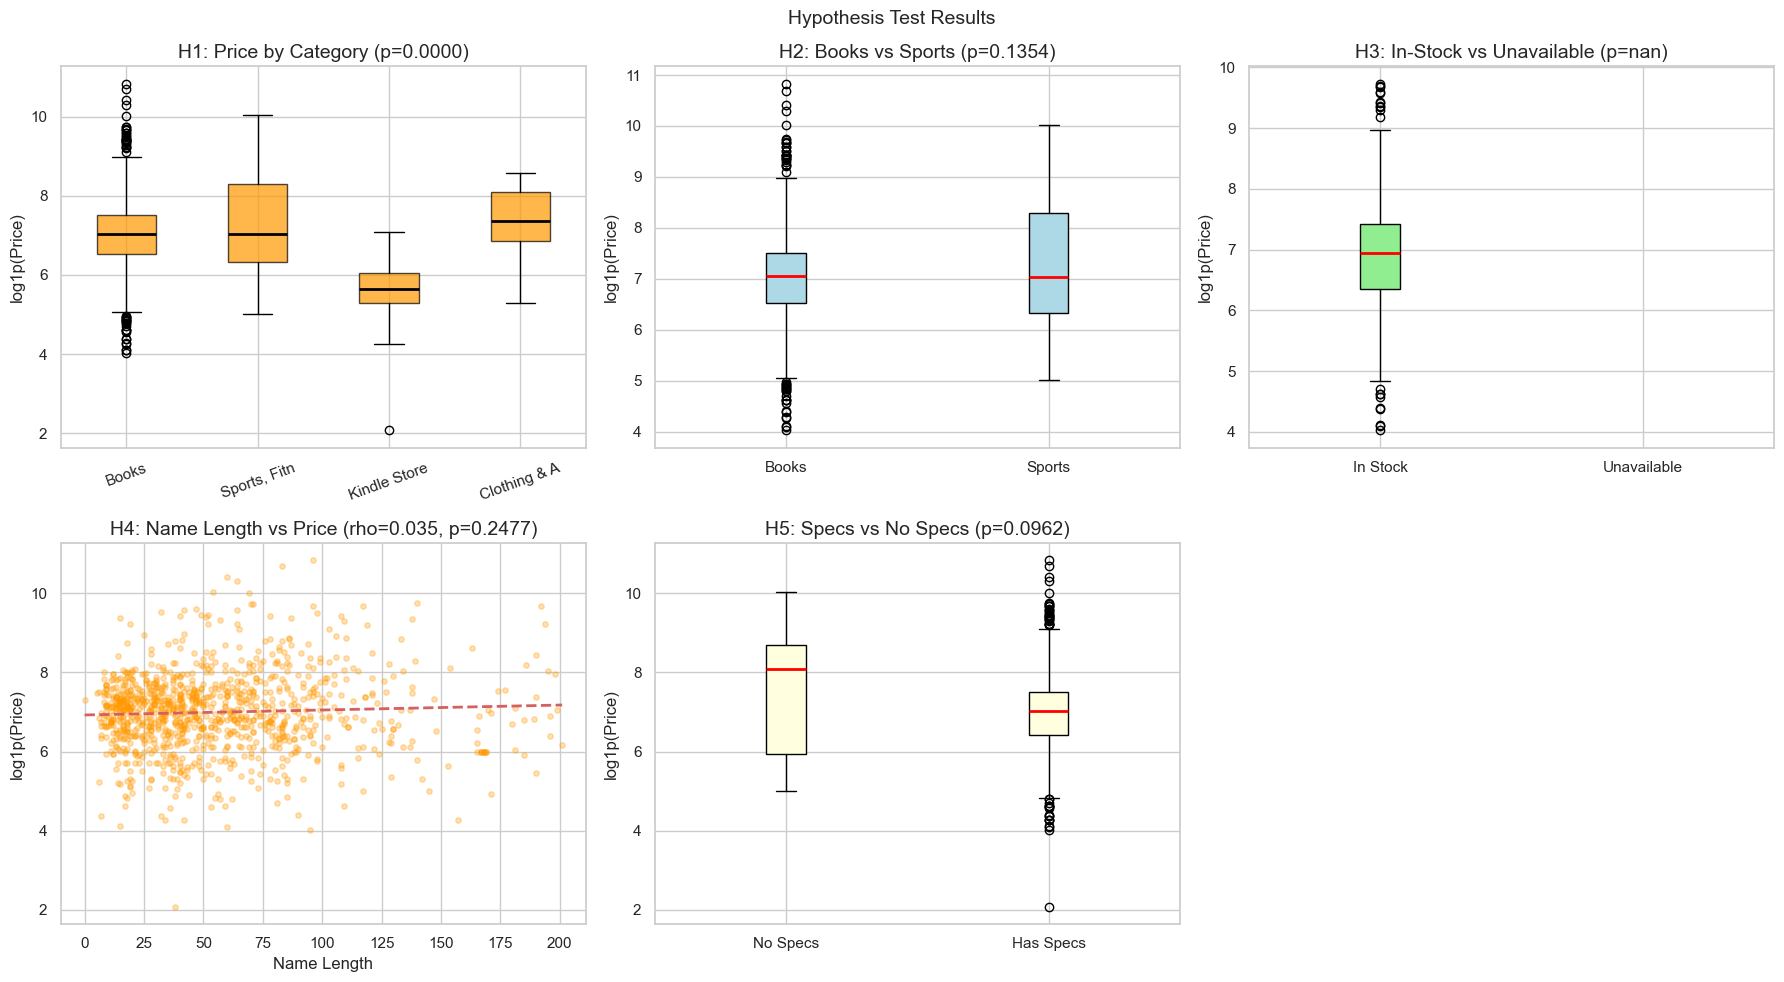

In [25]:
# Visualise hypothesis results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H1
axes[0,0].boxplot([np.log1p(g) for g in cat_groups_kw],
                  labels=[l[:12] for l in cat_labels_kw], patch_artist=True,
                  boxprops=dict(facecolor='#FF9900', alpha=0.7),
                  medianprops=dict(color='black', lw=2))
axes[0,0].set_title(f'H1: Price by Category (p={p1:.4f})')
axes[0,0].set_ylabel('log1p(Price)'); axes[0,0].tick_params(axis='x', rotation=20)

# H2
axes[0,1].boxplot([np.log1p(df_priced[df_priced['is_book']==1]['price_clean']),
                   np.log1p(df_priced[df_priced['is_sports']==1]['price_clean'])],
                  labels=['Books','Sports'], patch_artist=True,
                  boxprops=dict(facecolor='lightblue'),
                  medianprops=dict(color='red', lw=2))
axes[0,1].set_title(f'H2: Books vs Sports (p={p2:.4f})')
axes[0,1].set_ylabel('log1p(Price)')

# H3
axes[0,2].boxplot([np.log1p(df_priced[df_priced['is_instock']==1]['price_clean']),
                   np.log1p(df_priced[df_priced['is_unavailable']==1]['price_clean'])],
                  labels=['In Stock','Unavailable'], patch_artist=True,
                  boxprops=dict(facecolor='lightgreen'),
                  medianprops=dict(color='red', lw=2))
axes[0,2].set_title(f'H3: In-Stock vs Unavailable (p={p3:.4f})')
axes[0,2].set_ylabel('log1p(Price)')

# H4
axes[1,0].scatter(df_priced['name_length'], df_priced['log_price'],
                  alpha=0.3, color='#FF9900', s=15)
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[1,0].plot(x, m*x+b, 'r--', lw=2)
axes[1,0].set_title(f'H4: Name Length vs Price (rho={rho4:.3f}, p={p4:.4f})')
axes[1,0].set_xlabel('Name Length'); axes[1,0].set_ylabel('log1p(Price)')

# H5
axes[1,1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                   np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                  labels=['No Specs','Has Specs'], patch_artist=True,
                  boxprops=dict(facecolor='lightyellow'),
                  medianprops=dict(color='red', lw=2))
axes[1,1].set_title(f'H5: Specs vs No Specs (p={p5:.4f})')
axes[1,1].set_ylabel('log1p(Price)')

axes[1,2].set_visible(False)
plt.suptitle('Hypothesis Test Results', fontsize=14)
plt.tight_layout(); plt.show()

✅ ML dataset shape : (1087, 20)
✅ Features         : 18

Train: 869 | Test: 218


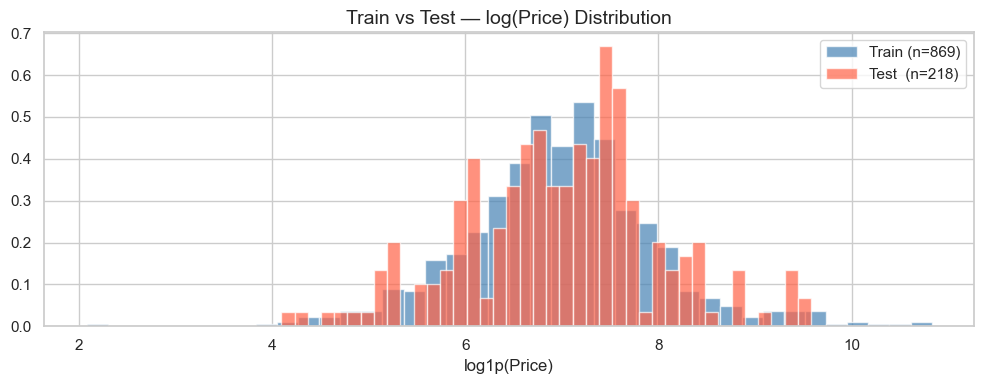

✅ Distributions look similar — good split!


In [26]:
# ============================================================
# SECTION 9 — ML Problem Framing
# ============================================================
FEATURE_COLS = [
    'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
    'is_book', 'is_kindle', 'is_sports',
    'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
    'is_instock', 'is_unavailable', 'is_lowstock',
    'primary_cat_enc', 'cat1_enc', 'avail_enc',
]

TARGET = 'log_price'

df_ml = df_priced[FEATURE_COLS + [TARGET, 'price_clean']].dropna().copy()
print(f'✅ ML dataset shape : {df_ml.shape}')
print(f'✅ Features         : {len(FEATURE_COLS)}')

X = df_ml[FEATURE_COLS]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nTrain: {len(X_train):,} | Test: {len(X_test):,}')

# Visualise split
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_train, bins=40, color='steelblue', alpha=0.7, label=f'Train (n={len(y_train)})', density=True)
ax.hist(y_test,  bins=40, color='tomato',    alpha=0.7, label=f'Test  (n={len(y_test)})',  density=True)
ax.set_title('Train vs Test — log(Price) Distribution')
ax.set_xlabel('log1p(Price)'); ax.legend()
plt.tight_layout(); plt.show()
print('✅ Distributions look similar — good split!')

## Model Comparison

| Model | Strengths | Weaknesses | Best For |
|---------|-----------|------------|-----------|
| Linear Regression | Fast, interpretable | Assumes linearity | Baseline |
| Ridge Regression | Handles multicollinearity | Still linear | Correlated features |
| Lasso Regression | Feature selection built-in | Can zero out useful features | Sparse features |
| Random Forest | Non-linear, robust | Less interpretable | Complex patterns |
| XGBoost / GBM | Best accuracy | Needs tuning | Tabular data |

---

## Evaluation Metrics

- **MAE** — Mean Absolute Error in log scale *(lower = better)*
- **RMSE** — Root Mean Squared Error *(penalizes large errors)*
- **R²** — Variance explained *(higher = better, max 1.0)*
- **MAE (₹)** — Back-transformed to INR for business interpretation

In [27]:
# ============================================================
# SECTION 10 — Evaluation Helpers
# ============================================================
results = {}

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae_inr = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    print(f'  📊 {name}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')
    results[name] = {'MAE_log': round(mae,4), 'RMSE_log': round(rmse,4),
                     'R2': round(r2,4), 'MAE_INR': round(mae_inr,0)}
    return y_pred

print('✅ Evaluation helpers ready.')



✅ Evaluation helpers ready.


In [28]:
# ============================================================
# SECTION 11 — Train All Models
# ============================================================
print('='*60)
print('TRAINING ALL MODELS')
print('='*60)

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = eval_model('Linear Regression', y_test, lr.predict(X_test_s))

# 2. Ridge Regression
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)
ridge_pred = eval_model('Ridge Regression', y_test, ridge.predict(X_test_s))

# 3. Lasso Regression
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_s, y_train)
lasso_pred = eval_model('Lasso Regression', y_test, lasso.predict(X_test_s))

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=10,
                            min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = eval_model('Random Forest', y_test, rf.predict(X_test))

# 5. XGBoost / GBM
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(n_estimators=400, learning_rate=0.05,
                                   max_depth=5, subsample=0.8,
                                   colsample_bytree=0.8, random_state=42, verbosity=0)
    xgb_model.fit(X_train, y_train)
    xgb_pred = eval_model('XGBoost', y_test, xgb_model.predict(X_test))
else:
    gbm = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                     max_depth=5, subsample=0.8, random_state=42)
    gbm.fit(X_train, y_train)
    xgb_pred = eval_model('Gradient Boosting', y_test, gbm.predict(X_test))

TRAINING ALL MODELS
  📊 Linear Regression:
     MAE (log)  = 0.7548  |  MAE (₹) = ₹1,188
     RMSE (log) = 0.9698  |  R²      = 0.0622
  📊 Ridge Regression:
     MAE (log)  = 0.7533  |  MAE (₹) = ₹1,186
     RMSE (log) = 0.9643  |  R²      = 0.0728
  📊 Lasso Regression:
     MAE (log)  = 0.7549  |  MAE (₹) = ₹1,187
     RMSE (log) = 0.9648  |  R²      = 0.0719
  📊 Random Forest:
     MAE (log)  = 0.6984  |  MAE (₹) = ₹1,110
     RMSE (log) = 0.8888  |  R²      = 0.2123
  📊 Gradient Boosting:
     MAE (log)  = 0.7403  |  MAE (₹) = ₹1,153
     RMSE (log) = 0.9462  |  R²      = 0.1073


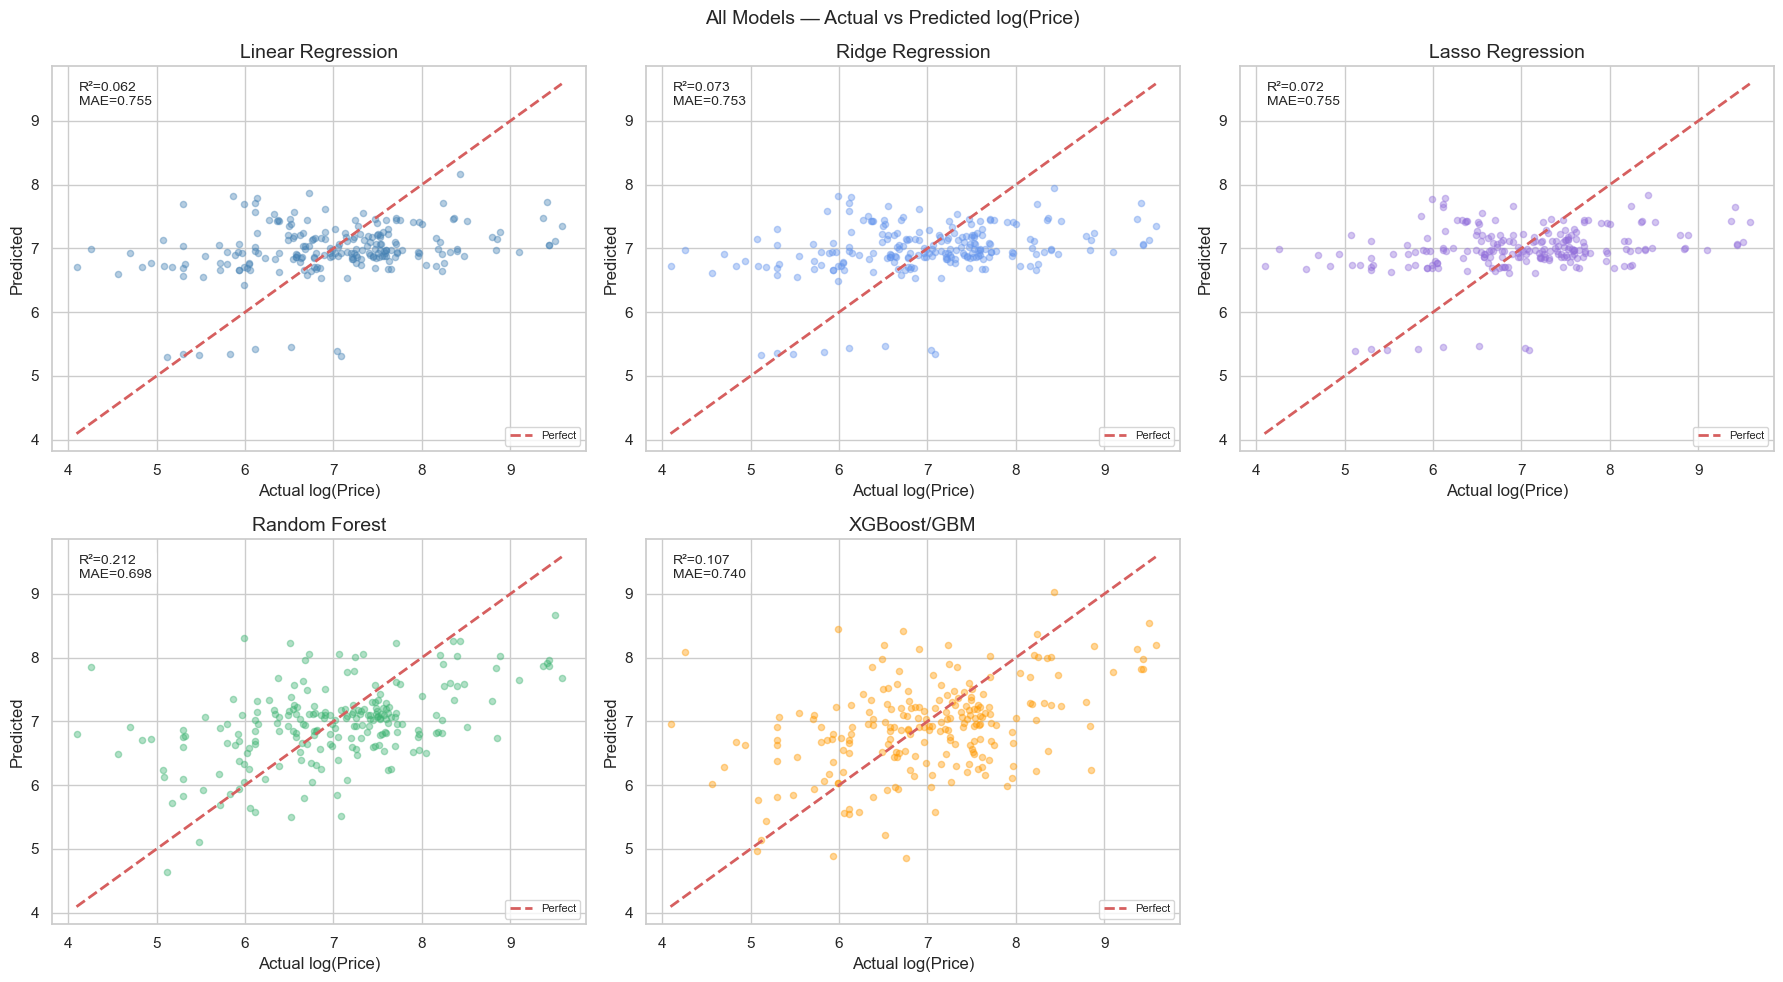

In [29]:

# Actual vs Predicted — all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
preds_all = [('Linear Regression', lr_pred, 'steelblue'),
             ('Ridge Regression',  ridge_pred, 'cornflowerblue'),
             ('Lasso Regression',  lasso_pred, 'mediumpurple'),
             ('Random Forest',      rf_pred,    'mediumseagreen'),
             ('XGBoost/GBM',        xgb_pred,   '#FF9900')]

for ax, (name, pred, color) in zip(axes.flatten(), preds_all):
    ax.scatter(y_test, pred, alpha=0.4, color=color, s=20)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect')
    r2v  = r2_score(y_test, pred)
    maev = mean_absolute_error(y_test, pred)
    ax.set_title(f'{name}')
    ax.set_xlabel('Actual log(Price)'); ax.set_ylabel('Predicted')
    ax.annotate(f'R²={r2v:.3f}\nMAE={maev:.3f}',
                xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    ax.legend(fontsize=8)

# FIX: Use flatten() to access the last individual subplot index
axes.flatten()[-1].set_visible(False)

plt.suptitle('All Models — Actual vs Predicted log(Price)', fontsize=14)
plt.tight_layout(); plt.show()

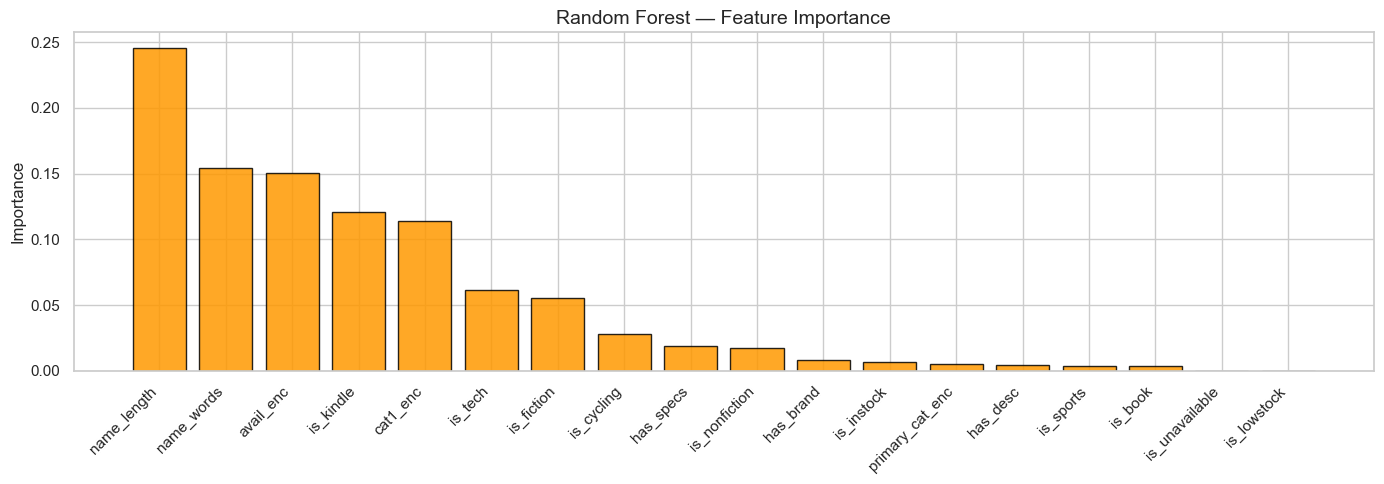

Top 10 most important features:
      Feature  Importance
  name_length    0.245198
   name_words    0.154159
    avail_enc    0.150559
    is_kindle    0.121088
     cat1_enc    0.114166
      is_tech    0.061342
   is_fiction    0.055122
   is_cycling    0.028367
    has_specs    0.019164
is_nonfiction    0.017840


In [30]:
# Feature importance — Random Forest
feat_imp = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(feat_imp['Feature'], feat_imp['Importance'],
        color='#FF9900', edgecolor='black', alpha=0.85)
plt.title('Random Forest — Feature Importance')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print('Top 10 most important features:')
print(feat_imp.head(10).to_string(index=False))

C:\Users\PC-25\AppData\Local\Temp\ipykernel_16812\1881029386.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(cat_groups, labels=cat_price.index, patch_artist=True,


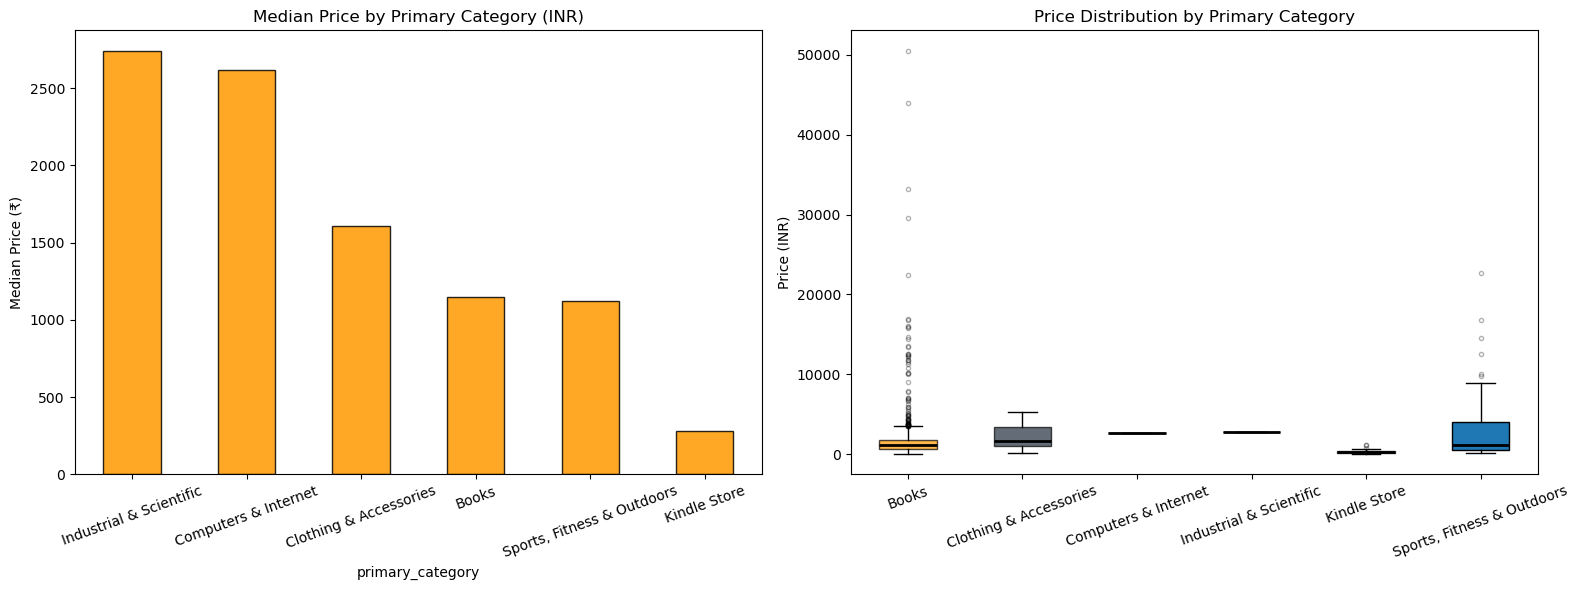

Price stats by primary category:
                              mean  median  count
primary_category                                 
Books                       1825.6  1145.0    955
Clothing & Accessories      2249.2  1606.5      6
Computers & Internet        2615.0  2615.0      1
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93


In [20]:
# Price by primary category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Primary Category (INR)')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=20)

# Boxplot
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]
bp = axes[1].boxplot(cat_groups, labels=cat_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
colors_cat = ['#FF9900','#232F3E','#146EB4','#E47911','#999']
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Price Distribution by Primary Category')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()
print('Price stats by primary category:')
print(cat_price.to_string())

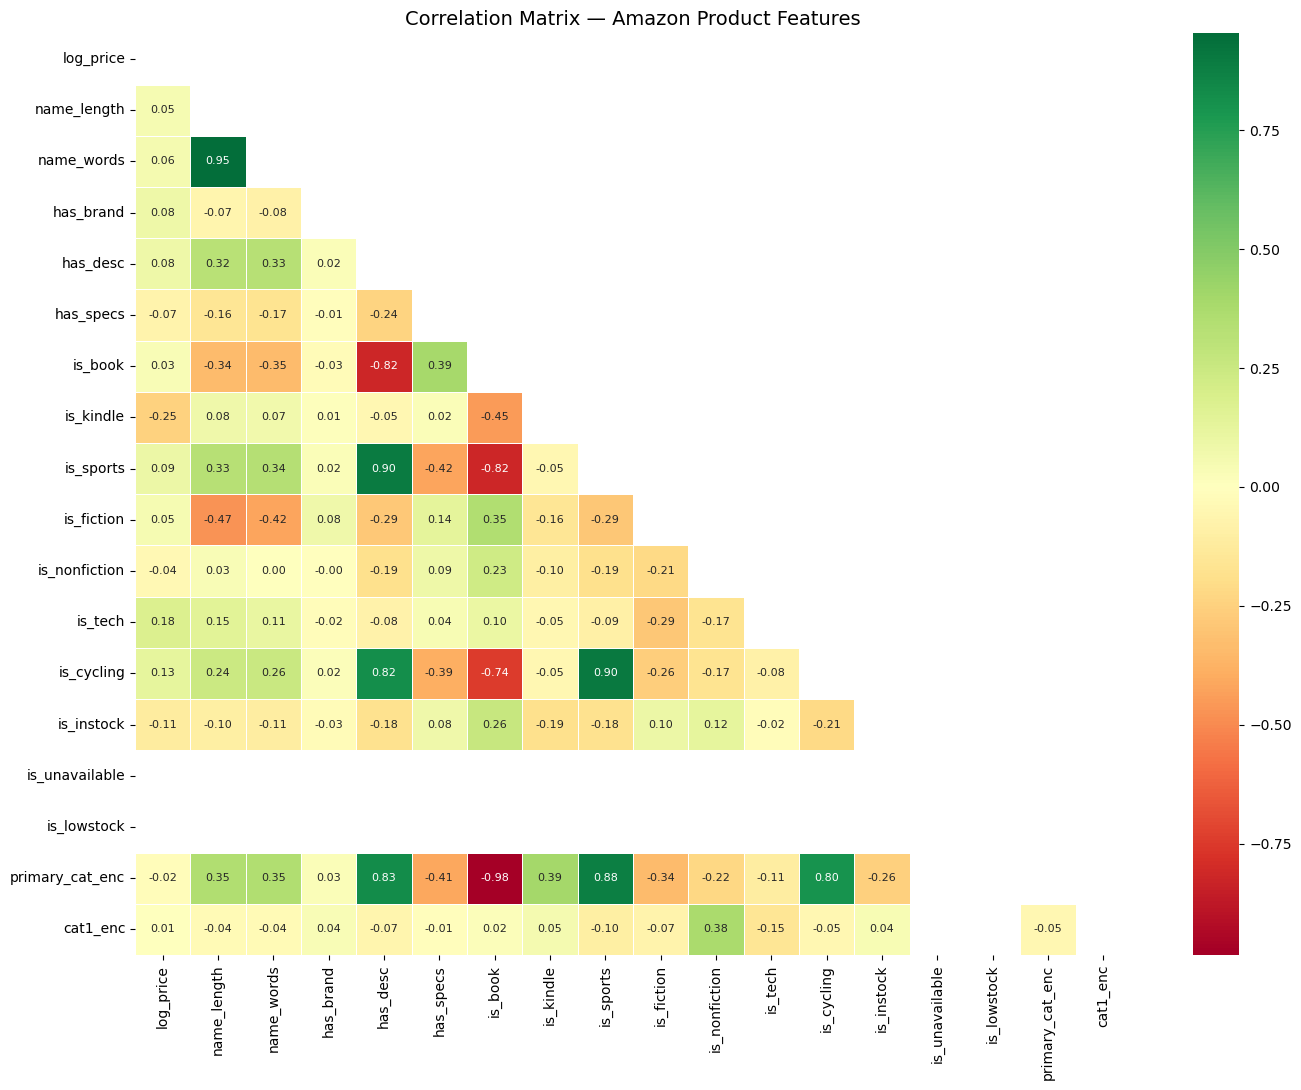

Top correlations with log_price:
is_tech            0.178700
is_cycling         0.126665
is_sports          0.091764
has_brand          0.083788
has_desc           0.083304
name_words         0.055104
is_fiction         0.052686
name_length        0.049775
is_book            0.034124
cat1_enc           0.006765
primary_cat_enc   -0.019787
is_nonfiction     -0.044517
has_specs         -0.074902
is_instock        -0.114018
is_kindle         -0.246647
is_unavailable          NaN
is_lowstock             NaN


In [21]:
# ============================================================
# SECTION 7 — Correlation Analysis
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Matrix — Amazon Product Features', fontsize=14)
plt.tight_layout(); plt.show()

print('Top correlations with log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())